# 06 · Modelo: Red neuronal (Keras)

**Proyecto Final — Machine Learning y Deep Learning**

Este notebook se centra en **un solo modelo**: capas de neuronas (*deep learning*) que capturan relaciones complejas. Sigue la misma estructura que el resto de notebooks de modelo, para poder compararlos con facilidad.

> 📖 Términos técnicos explicados en `docs/glosario.md`. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb); la comparación de todos los modelos, en [`07_comparativa_modelos.ipynb`](07_comparativa_modelos.ipynb).

## 1. Cómo funciona

Una **red neuronal multicapa** (*perceptrón multicapa*) apila **capas de neuronas**. Cada neurona combina sus entradas con unos **pesos** y aplica una **función de activación** (ReLU) que aporta no linealidad; la capa final (sigmoide) devuelve la **probabilidad** de cancelación.

Aprende ajustando los pesos por **descenso de gradiente** (*backpropagation*), minimizando el error capa a capa. Puede capturar relaciones **muy complejas**, pero necesita más datos y cuidado con el sobreajuste, que aquí controlamos con **dropout** y **early stopping**.

## 2. Los datos

Usamos el **mismo preprocesado compartido** por todos los modelos (`src/preprocessing.py`): imputación de huecos, estandarización de las numéricas y *one-hot* de las categóricas. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb). Cargamos y dividimos en train/test (estratificado, semilla fija) con `load_and_prepare()`.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.pipeline import Pipeline
from src import config
from src.data_loader import load_and_prepare
from src.preprocessing import build_preprocessor
from src.notebook_utils import evaluar, plot_confusion_roc  # lógica compartida
from src.model_viz import visualizar_modelo

X_train, X_test, y_train, y_test = load_and_prepare()
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

Entrenamiento: (95368, 28) | Prueba: (23842, 28)


## 3. Los hiperparámetros: ¿qué controla cada uno?

Los **hiperparámetros** son los ajustes que fijamos *antes* de entrenar (no se aprenden de los datos). Estos son los principales de este modelo:

| Hiperparámetro | Qué controla |
|---|---|
| `hidden_units` | Nº de neuronas por capa oculta (la **capacidad** del modelo). |
| `dropout` | Fracción de neuronas que se "apagan" al azar al entrenar (**regularización**). |
| `learning_rate` | Tamaño del paso del optimizador (Adam). |
| `epochs` / `batch_size` | Nº de pasadas por los datos / tamaño del lote. |
| `early_stopping_patience` | Épocas sin mejorar la validación antes de **parar** (evita sobreajuste). |

## 4. Entrenamiento y evaluación (parámetros base)

Entrenamos el modelo con los hiperparámetros base y lo evaluamos sobre el conjunto de prueba (datos que no vio al entrenar).

In [2]:
# Pipeline = preprocesado + modelo (con los hiperparámetros base del proyecto)
from src.model_trainer import KerasMLPClassifier
modelo = Pipeline([('preprocessor', build_preprocessor()), ('model', KerasMLPClassifier(**config.NN_PARAMS, random_state=config.RANDOM_STATE))])
modelo.fit(X_train, y_train)
auc_base = evaluar(modelo, X_test, y_test, 'Base')

Base         | accuracy=0.8746 | precision=0.8502 | recall=0.8034 | f1=0.8262 | roc_auc=0.9483


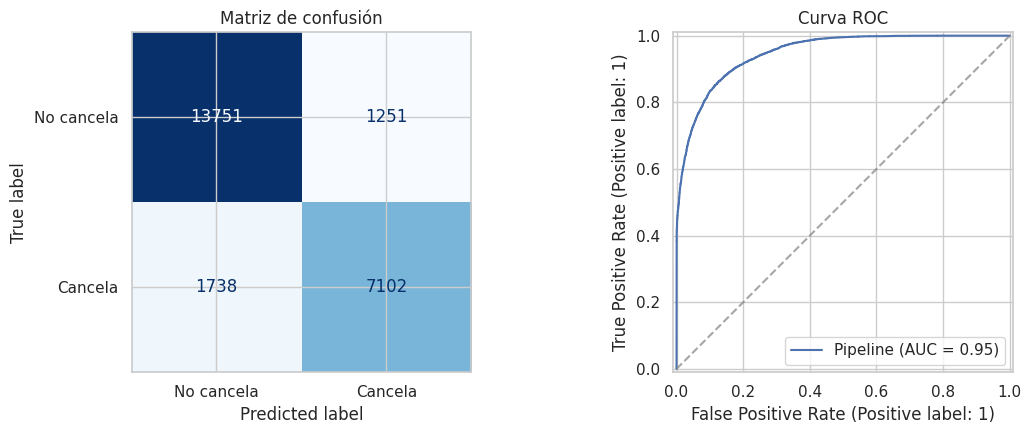

In [3]:
# Matriz de confusión y curva ROC (helper compartido en src/notebook_utils.py)
plot_confusion_roc(modelo, X_test, y_test)

## 5. Visualización del modelo

Visualizamos un **esquema de su arquitectura**: las capas y cuántas neuronas tiene cada una. (lo dibuja `src/model_viz.py`, que elige la representación adecuada según el tipo de modelo).

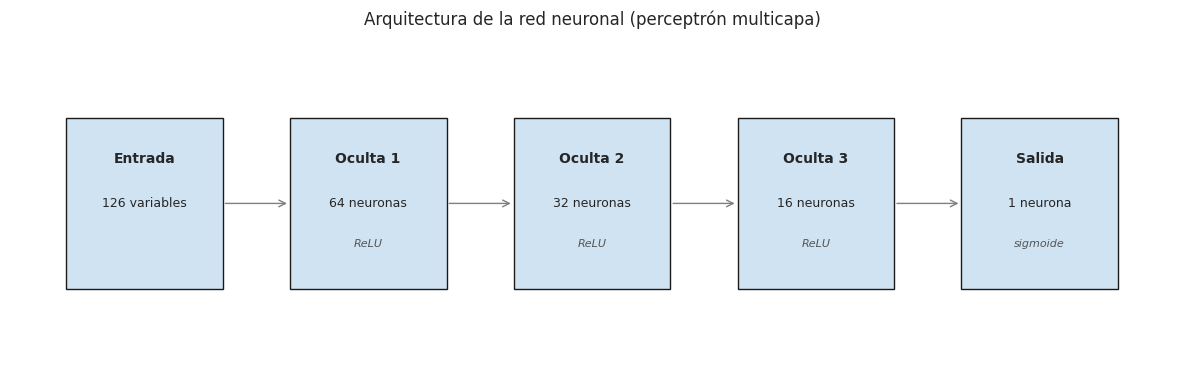

In [4]:
visualizar_modelo(modelo, X_train)  # dibuja lo adecuado según el tipo de modelo

## 6. Regularización y *early stopping*

Ajustar una red por **búsqueda en rejilla** sería desproporcionadamente costoso. En su lugar, la red se **autorregula** durante el entrenamiento con **dropout** (apaga neuronas al azar) y **early stopping** (para cuando la validación deja de mejorar y restaura los mejores pesos). La curva de aprendizaje muestra ese proceso:

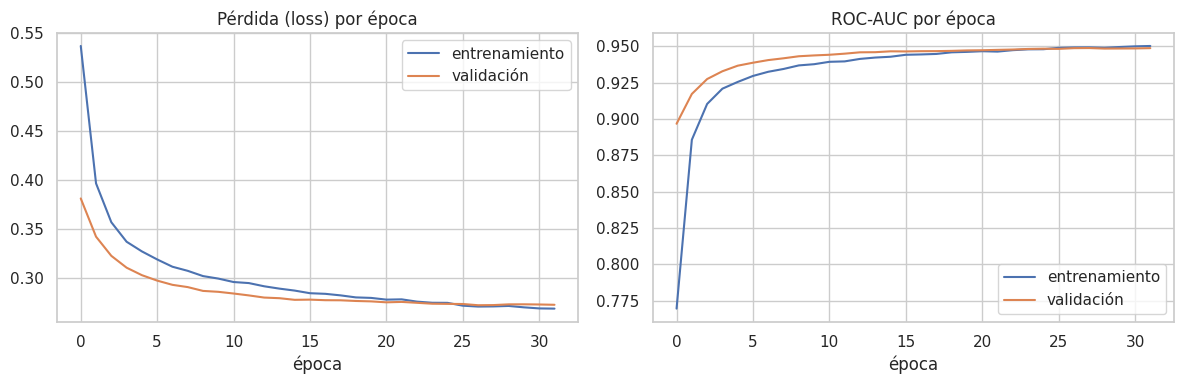

La red entrenó 32 épocas; early stopping restauró los mejores pesos.


In [5]:
# La red no se ajusta con búsqueda en rejilla (sería costosísimo); se regulariza
# con dropout y EARLY STOPPING. Vemos su curva de aprendizaje por época.
hist = modelo.named_steps['model'].history_.history
auc_k = next(k for k in hist if 'auc' in k and not k.startswith('val'))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(hist['loss'], label='entrenamiento'); a1.plot(hist['val_loss'], label='validación')
a1.set_title('Pérdida (loss) por época'); a1.set_xlabel('época'); a1.legend()
a2.plot(hist[auc_k], label='entrenamiento'); a2.plot(hist['val_' + auc_k], label='validación')
a2.set_title('ROC-AUC por época'); a2.set_xlabel('época'); a2.legend()
plt.tight_layout(); plt.show()
print(f'La red entrenó {len(hist["loss"])} épocas; early stopping restauró los mejores pesos.')

## 7. Resultado final y cuándo usar este modelo

**Cuándo conviene:** con relaciones **muy no lineales** y abundancia de datos. Aquí compite de cerca, pero **XGBoost la supera**: en datos tabulares medianos, el boosting de árboles suele ganar a las redes.